# 🌾 False Smut YOLOv11 Segmentation Training Pipeline

This notebook handles the dataset mounting, model training, validation, and testing for the **False Smut** disease using ultralytics YOLOv11 segmentation.
*This is the cleaned and finalized version of the training pipeline.*
---


## 📦 Phase 1: Environment Setup


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies
!pip install -U ultralytics matplotlib opencv-python-headless tqdm


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 📂 Phase 2: Define Dataset Paths
Ensure the dataset paths are correct and accessible.


In [2]:
import yaml
import os

# Define the root dataset directory
DATASET = "/content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11"

yaml_path = os.path.join(DATASET, "data.yaml")

# Fix the internal path reference in data.yaml just in case
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['path'] = DATASET   # Enforce correct root path

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print(f"data.yaml configured perfectly at: {yaml_path}")


data.yaml configured perfectly at: /content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/data.yaml


## 🚀 Phase 3: Model Training
We use `yolo11n-seg.pt` (nano) as the base model for fast inference.
The `project` and `name` arguments ensure the `.pt` weights are automatically saved to your permanent `results` folder on Drive.


In [3]:
from ultralytics import YOLO

# Upgraded to Small model for better accuracy
model = YOLO("yolo11m-seg.pt")

model.train(
    data="/content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=40,
    cos_lr=True,
    cache=True,
    pretrained=True,
    project="/content/drive/MyDrive/PaddyPanicleProject/results",
    name="false_smut_final_m",
    exist_ok=True,
    # Augmentation
    hsv_h=0.01,
    hsv_s=0.6,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.3,
    flipud=0.2,
    fliplr=0.5,
)

print("\n✅ Training Complete! Weights saved to Google Drive.")


Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.6, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=false_smut_final_m, nbs=64, nms=False, opset=

## 📊 Phase 4: Validation & Metrics
Evaluate the trained model's performance on the validation set.


In [4]:
from ultralytics import YOLO

# Load the newly trained best weights
best_weights = "/content/drive/MyDrive/PaddyPanicleProject/results/false_smut_final_m/weights/best.pt"
trained_model = YOLO(best_weights)

# Run validation
metrics = trained_model.val()

print("\n--- Validation Metrics ---")
print(f"mAP50-95 (Seg): {metrics.seg.map:.4f}")
print(f"mAP50 (Seg):    {metrics.seg.map50:.4f}")


Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-seg summary (fused): 139 layers, 22,336,854 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 22.9±6.9 MB/s, size: 58.4 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1kLeaE77JygL_DGcYKmEqHoqmOfRCW_8A/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/valid/labels.cache... 64 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 16.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.2s/it 8.8s
                   all         64        188      0.958      0.755      0.894      0.576      0.966      0.761      0.881      0.594
Rice false smut - v3 2026-02-19 12-51am         64        188      0.958      0.755      0.894      0.576      0.966      0.761      0.881      0.594
Speed: 11.1ms preprocess, 34.7ms inference, 

## 🖼️ Phase 5: Test Inference & Visualization
Run the model on the test dataset and visually verify the segmentation masks.
Outputs will be saved directly to the permanent `results` drive folder.



image 1/1 /content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/test/images/RiceFalseSmut-0008_jpg.rf.5fdfc66f5158c8becddb536ec573f8b5.jpg: 640x640 1 Rice false smut - v3 2026-02-19 12-51am, 50.2ms
Speed: 2.2ms preprocess, 50.2ms inference, 13.0ms postprocess per image at shape (1, 3, 640, 640)


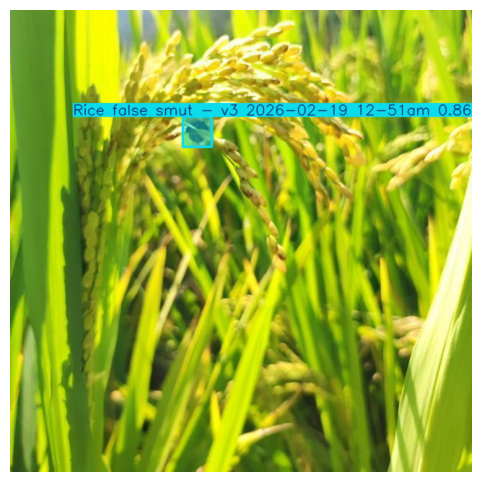


image 1/1 /content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/test/images/RiceFalseSmut-0004_jpg.rf.13c18139d310798755c5e55942a49c92.jpg: 640x640 3 Rice false smut - v3 2026-02-19 12-51ams, 38.3ms
Speed: 2.3ms preprocess, 38.3ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)


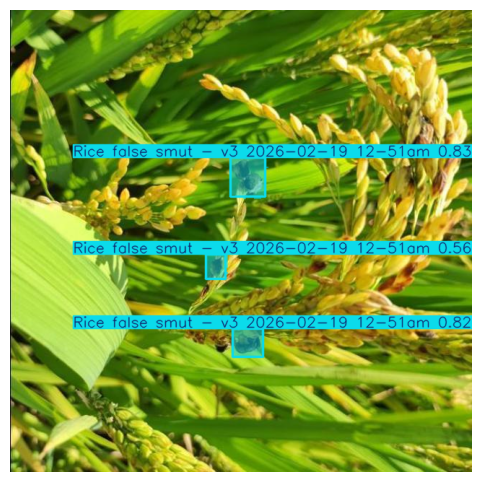


image 1/1 /content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/test/images/RiceFalseSmut-0036_jpg.rf.d5f5942cacb3d294a6e5b1ea1d588dfa.jpg: 640x640 1 Rice false smut - v3 2026-02-19 12-51am, 38.3ms
Speed: 2.5ms preprocess, 38.3ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)


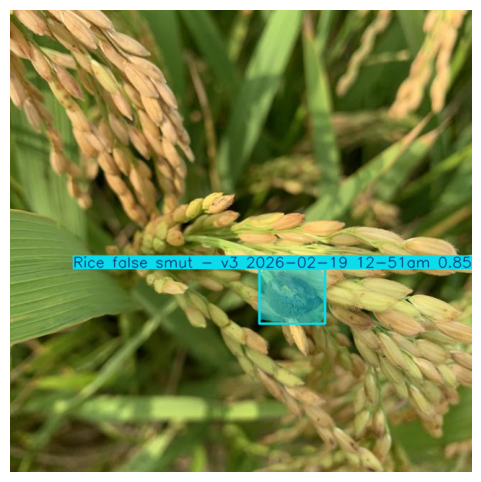


image 1/1 /content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/test/images/RiceFalseSmut-0068_jpg.rf.6a750a70dc47979c49744efd4e15ac3a.jpg: 640x640 2 Rice false smut - v3 2026-02-19 12-51ams, 38.2ms
Speed: 2.3ms preprocess, 38.2ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)


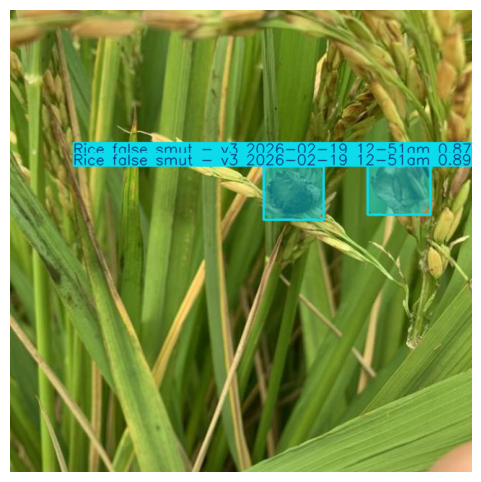


image 1/1 /content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/test/images/RiceFalseSmut-0070_jpg.rf.adaf0406b35cab7139b06e0f2e5e46b8.jpg: 640x640 1 Rice false smut - v3 2026-02-19 12-51am, 38.2ms
Speed: 2.2ms preprocess, 38.2ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)


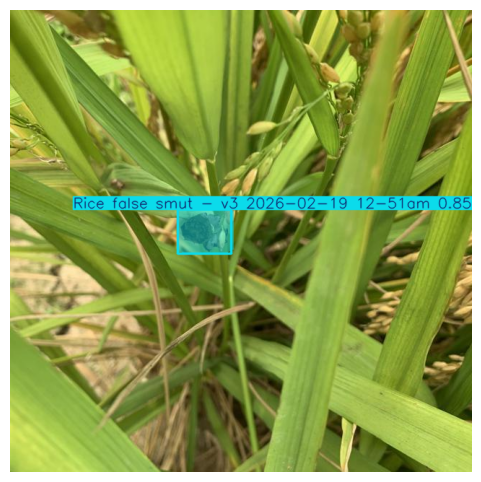


image 1/1 /content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/test/images/RiceFalseSmut-0017_jpg.rf.261da6a5b202464864d64d0c9571e787.jpg: 640x640 2 Rice false smut - v3 2026-02-19 12-51ams, 38.3ms
Speed: 2.4ms preprocess, 38.3ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


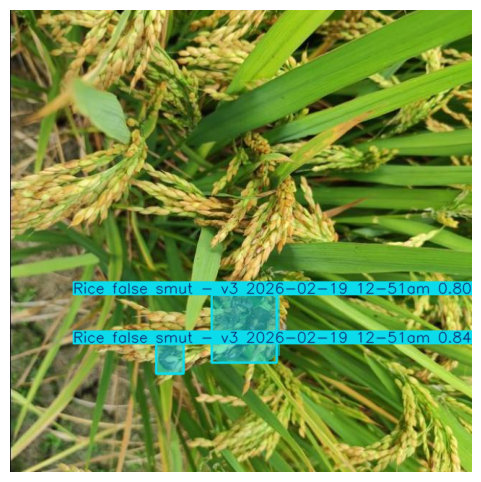


✅ Inference complete! Plotted images saved to Google Drive.


In [5]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

# Load the trained model
best_weights = "/content/drive/MyDrive/PaddyPanicleProject/results/false_smut_final_m/weights/best.pt"
m = YOLO(best_weights)

# Define test folder and save location
test_images_dir = "/content/drive/MyDrive/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/test/images"
test_imgs = list(Path(test_images_dir).glob("*.jpg")) + list(Path(test_images_dir).glob("*.png"))

# Run inference and save annotated results natively to Drive
for img in test_imgs[:6]:  # Running on the first 6 images to preview
    results = m.predict(
        source=str(img),
        imgsz=640,
        conf=0.25,
        project="/content/drive/MyDrive/PaddyPanicleProject/results",
        name="false_smut_predict",
        save=False
    )

    # Plotting right here in the notebook output
    res_img = results[0].plot()
    res_img_rgb = cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(res_img_rgb)
    plt.axis("off")
    plt.show()

print("\n✅ Inference complete! Plotted images saved to Google Drive.")


---
## 📊 Model Evaluation & Metrics

This section automatically evaluates the fully trained model on the validation set
and extracts the key performance metrics (Precision, Recall, mAP50, mAP50-95).
Use these standard metrics for your capstone project report.

Running full exhaustive validation suite...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-seg summary (fused): 139 layers, 22,336,854 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 36.6±7.4 MB/s, size: 68.2 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1kLeaE77JygL_DGcYKmEqHoqmOfRCW_8A/PaddyPanicleProject/datasets/rice_false_smut_segmentation_yolov11/valid/labels.cache... 64 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 26.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.8s/it 7.0s
                   all         64        188      0.958      0.755      0.894      0.576      0.966      0.761      0.881      0.594
Rice false smut - v3 2026-02-19 12-51am         64        188      0.958      0.755      0.894      0.576      0.966      0.761      0.881      0.594


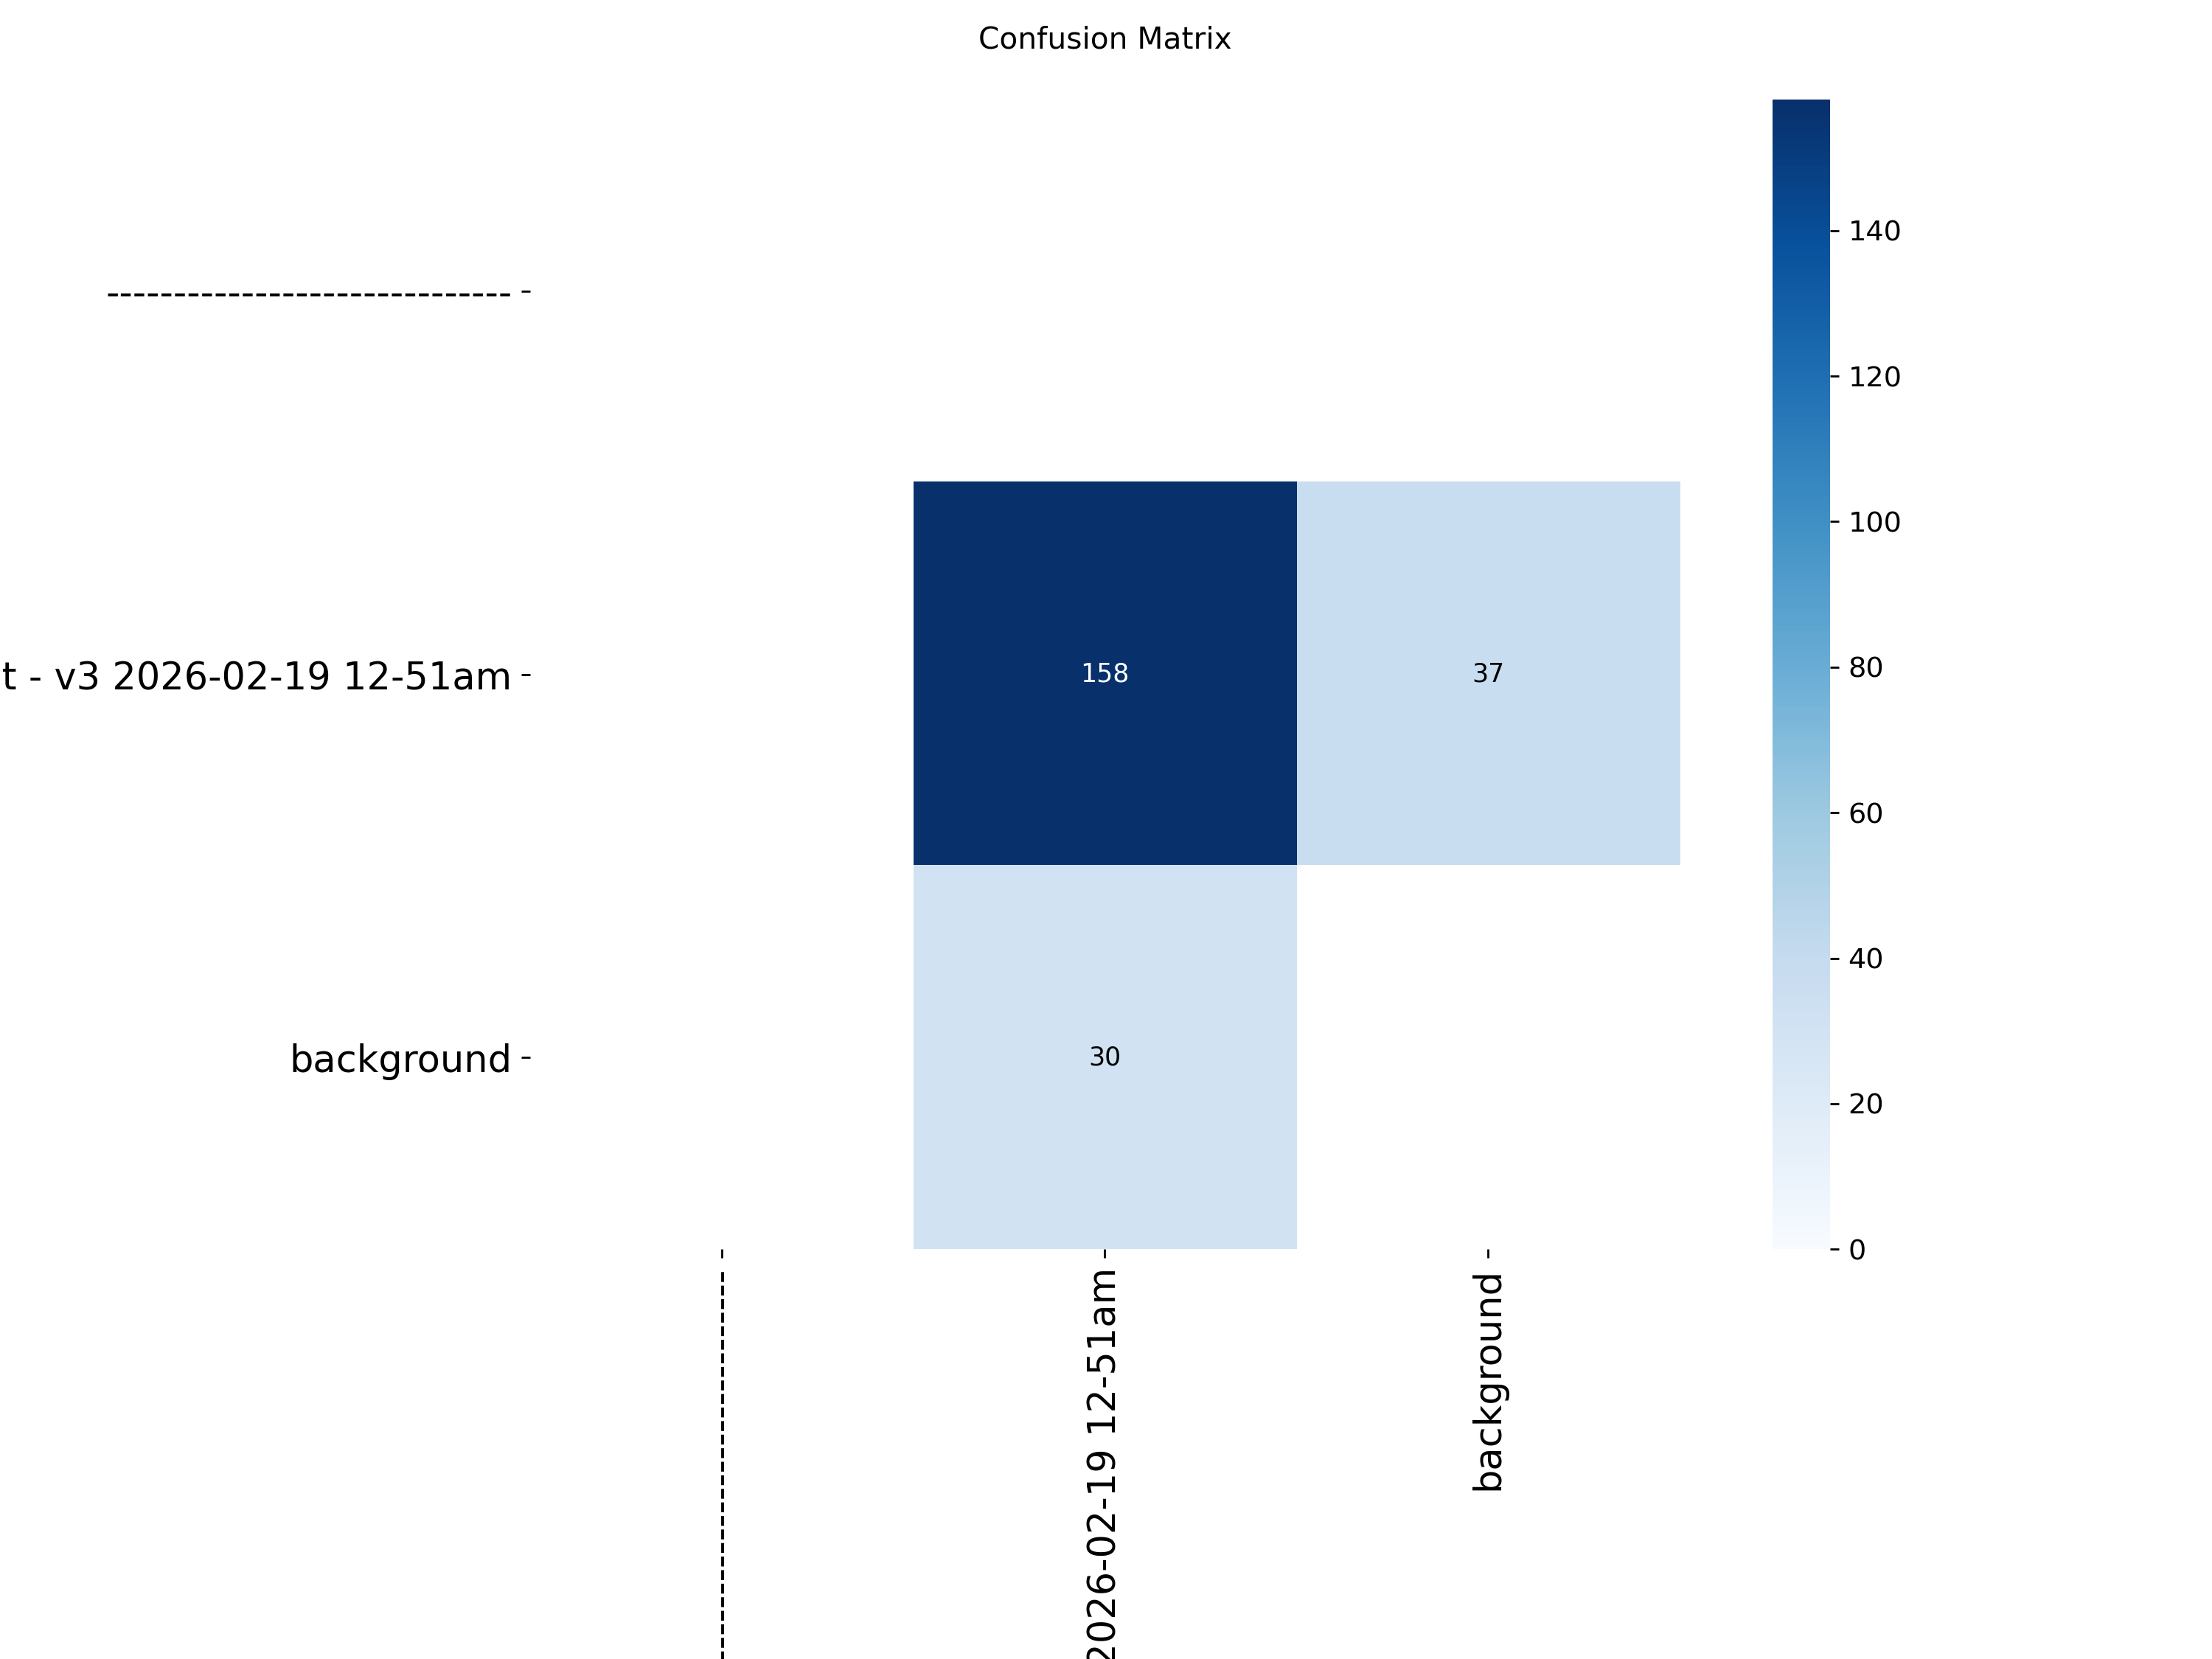


► confusion_matrix_normalized.png:


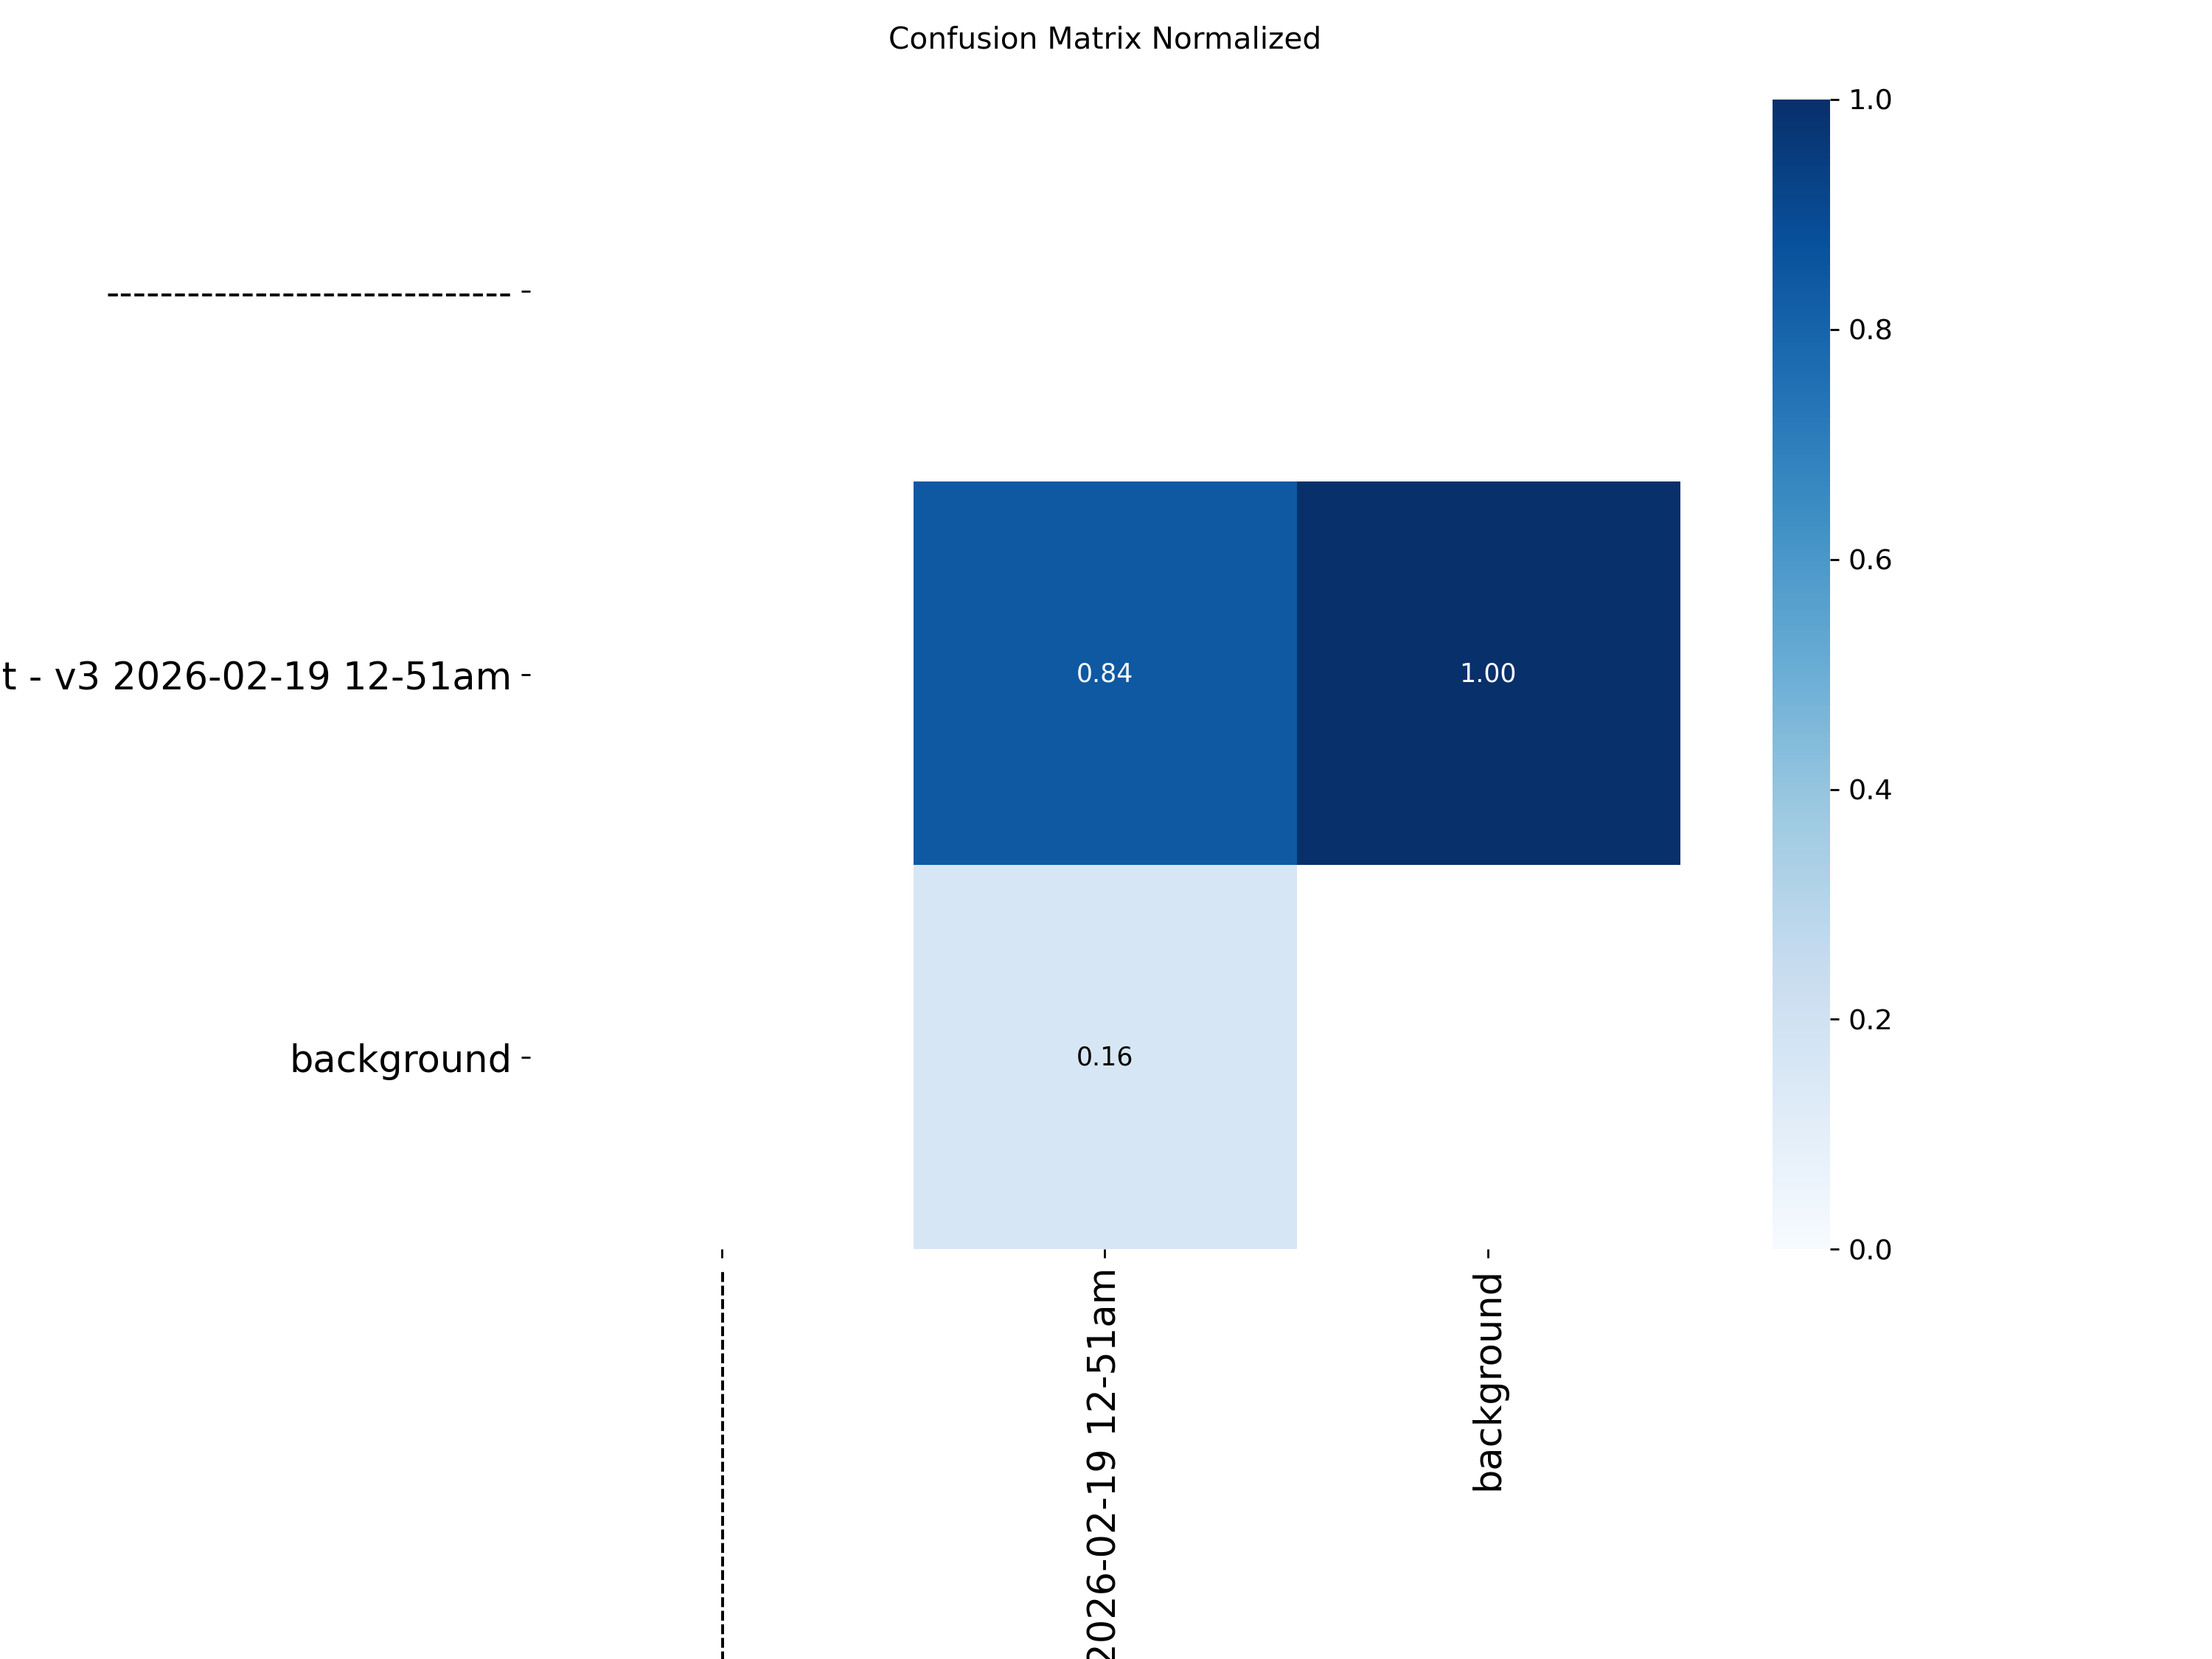

In [6]:
# ── EXTRACT EVERY SINGLE AVAILABLE METRIC, GRAPH, AND STATISTIC ──
import pandas as pd
from IPython.display import display, Image
import os

print("Running full exhaustive validation suite...")
# 1. Run validation engine
metrics = model.val()
res = metrics.results_dict
speed = metrics.speed

print("\n" + "═"*70)
print(f"   EXHAUSTIVE YOLOv11 PERFORMANCE MATRICES")
print("═"*70)

# 2. Calculate Standard Box Metrics
if 'metrics/precision(B)' in res:
    p_box = res['metrics/precision(B)']
    r_box = res['metrics/recall(B)']
    map50_box = res['metrics/mAP50(B)']
    map95_box = res['metrics/mAP50-95(B)']
    f1_box = 2 * (p_box * r_box) / (p_box + r_box) if (p_box + r_box) > 0 else 0

    print("  [BOUNDING BOX DETECTION]")
    print(f"  Precision (P)          : {p_box:.4f}  ({p_box*100:.2f}%)")
    print(f"  Recall (R)             : {r_box:.4f}  ({r_box*100:.2f}%)")
    print(f"  F1-Score               : {f1_box:.4f}  ({f1_box*100:.2f}%)")
    print(f"  mAP@50 (IoU=0.50)      : {map50_box:.4f}  ({map50_box*100:.2f}%)")
    print(f"  mAP@50-95 (Strict Avg) : {map95_box:.4f}  ({map95_box*100:.2f}%)")
    print("──────────────────────────────────────────────────────────────────────")

# 3. Calculate Segmentation Mask Metrics
if 'metrics/precision(M)' in res:
    p_mask = res['metrics/precision(M)']
    r_mask = res['metrics/recall(M)']
    map50_mask = res['metrics/mAP50(M)']
    map95_mask = res['metrics/mAP50-95(M)']
    f1_mask = 2 * (p_mask * r_mask) / (p_mask + r_mask) if (p_mask + r_mask) > 0 else 0

    print("\n  [SEGMENTATION MASKS]")
    print(f"  Mask Precision         : {p_mask:.4f}  ({p_mask*100:.2f}%)")
    print(f"  Mask Recall            : {r_mask:.4f}  ({r_mask*100:.2f}%)")
    print(f"  Mask F1-Score          : {f1_mask:.4f}  ({f1_mask*100:.2f}%)")
    print(f"  Mask mAP@50            : {map50_mask:.4f}  ({map50_mask*100:.2f}%)")
    print(f"  Mask mAP@50-95         : {map95_mask:.4f}  ({map95_mask*100:.2f}%)")
    print("──────────────────────────────────────────────────────────────────────")

# 4. Inference Speed Metrics
print("\n  [INFERENCE & PRE-PROCESSING SPEED (milliseconds/image)]")
print(f"  Pre-process Speed      : {speed.get('preprocess', 0.0):.2f} ms")
print(f"  Inference Speed        : {speed.get('inference', 0.0):.2f} ms")
print(f"  Post-process (NMS)     : {speed.get('postprocess', 0.0):.2f} ms")
print(f"  Total Time per Image   : {sum(speed.values()):.2f} ms")
print("──────────────────────────────────────────────────────────────────────")

# 5. The Raw Dictionary Dump (Fitness, Class Overlap, Loss, Everything Else)
print("\n  [ALL OTHER RAW INTERNAL METRICS]")
for key, value in res.items():
    if 'metrics/' not in key:  # already printed clearly above
        print(f"  {key:<22} : {value:.6f}")

print("\n" + "═"*70)
print("✅ All numerical metrics extracted.")

# 6. Auto-Display Graphical Metrics (Confusion Matrix, PR Curve, F1 Curve)
# Ultralytics saves these automatically to the active run directory (e.g. runs/detect/val)
val_dir = metrics.save_dir
graphs = ['confusion_matrix.png', 'confusion_matrix_normalized.png', 'F1_curve.png', 'PR_curve.png']
print("\nLoading YOLO validation graphics...")
for g in graphs:
    graph_path = os.path.join(val_dir, g)
    if os.path.exists(graph_path):
        print(f"\n► {g}:")
        display(Image(filename=graph_path, width=800))
